Optimal point:
[np.float64(0.23324090887154297), np.float64(1.577118729504639), np.float64(-0.13209387524077823), np.float64(-1.4362175959243255), np.float64(-0.9058566363332975), np.float64(1.676217972377148), np.float64(3.214209296622695), np.float64(1.0915845917143945)]
Optimal value:
19.21747754732893

Najbolja tura (redosled gradova):
[4, 5, 3, 1, 8, 2, 6, 7]

Duzina najbolje ture:
19.21747754732893


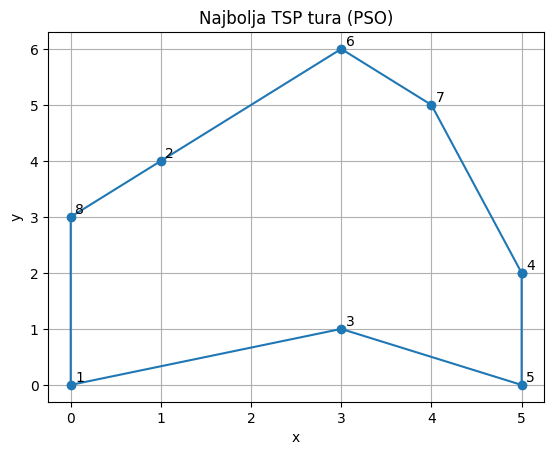

In [2]:
# Load basic numeric packages (isto kao u ipynb)
import numpy as np
import random as random
import math as math
import matplotlib.pyplot as plt

class myOptions:
    def __init__(self):
        self.npart          = 30;       # The number of particles.
        self.niter          = 100;      # The number of iterations.
        self.cbi            = 2.5;      # Initial value of the individual-best acceleration factor.
        self.cbf            = 0.5;      # Final value of the individual-best acceleration factor.
        self.cgi            = 0.5;      # Initial value of the global-best acceleration factor.
        self.cgf            = 2.5;      # Final value of the global-best acceleration factor.
        self.wi             = 0.9;      # Initial value of the inertia factor.
        self.wf             = 0.4;      # Final value of the inertia factor.
        self.vmax           = math.inf;      # Absolute speed limit. (u ipynb stoji, ovde ga ne koristimo dodatno)
        self.vmaxscale      = float('nan');  # Relative speed limit.
        self.vspaninit      = 1;        # The initial velocity span.
        self.initpopulation = float('nan');
        self.initoffset     = 0;        # Offset of the initial population.
        self.initspan       = 1;        # Span of the initial population.
        self.trustoffset    = 0;        # Ako bi offset bio "dobra pretpostavka" (ne koristimo ovde)


class Error(Exception):
    def __init__(self, message):
        self.message = message


class Particle:
    def __init__(self,x0,num_dimensions,options):
        self.position_i=[]          # pozicija cestice (ovde: 8 realnih brojeva)
        self.velocity_i=[]          # brzina cestice (8 realnih brojeva)
        self.pos_best_i=[]          # najbolja pozicija koju je cestica do sad videla
        self.fitness_best_i=-1      # najbolja (najmanja) duzina ture za ovu cesticu
        self.fitness_i=-1           # trenutna duzina ture
        self.num_dimensions=num_dimensions

        # Inicijalne pozicije i brzine
        for i in range(0,num_dimensions):
            self.velocity_i.append((np.random.rand()-0.5)*2*options.vspaninit)
            self.position_i.append(x0[i][0])

    # racuna fitness i azurira individual best
    def evaluate(self,costFunc):
        self.fitness_i=costFunc(self.position_i)

        # Ako je prvi put ili je bolje (manje) nego do sad, pamti
        if self.fitness_i < self.fitness_best_i or self.fitness_best_i==-1:
            self.pos_best_i=np.copy(self.position_i)
            self.fitness_best_i=np.copy(self.fitness_i)

    # linearna promena parametara kroz iteracije
    def linrate(self,xmax, xmin, tmax, tmin, t):
        x = xmin + ((xmax-xmin)/(tmax-tmin))*(tmax-t)
        return x

    # azuriranje brzine
    def update_velocity(self,pos_best_g,maxiter,iter,opt):

        # PSO parametri koji se menjaju linearno kroz vreme
        w = self.linrate(opt.wf, opt.wi, maxiter, 0, iter)
        cp = self.linrate(opt.cbf, opt.cbi, maxiter, 0, iter)
        cg = self.linrate(opt.cgf, opt.cgi, maxiter, 0, iter)

        for i in range(0,self.num_dimensions):
            r1=random.random()
            r2=random.random()

            # "Vuce" ka svom najboljem i ka globalno najboljem
            vel_cognitive=cp*r1*(self.pos_best_i[i]-self.position_i[i])
            vel_social=cg*r2*(pos_best_g[i]-self.position_i[i])

            self.velocity_i[i]=w*self.velocity_i[i]+vel_cognitive+vel_social

    # pomeranje cestice
    def update_position(self):
        for i in range(0,self.num_dimensions):
            self.position_i[i]=self.position_i[i]+self.velocity_i[i]


class PSO():
    def __init__(self,costFunc,num_dimensions,options):
        self.pos_best_g=[]
        self.fitness_best_g=-1

        fitness_best_g=-1          # best fitness in population
        pos_best_g=[]              # best position in population

        maxiter=options.niter
        num_particles=options.npart
        population=[]

        # Inicijalizacija populacije
        if ((~np.isnan(options.initpopulation)).all()):
            b=np.shape(options.initpopulation)
            if(np.size(b)==1):
                pno=b[0]
                pdim=1
            if (pno!=options.npart) or (pdim!=options.nvar):
                 raise Error("The format of initial population is inconsistent with desired population")
            population=options.initpopulation
        else:
            for i in range(0,num_particles):
                x0=(np.random.rand(num_dimensions,1)-0.5)*2*options.initspan + options.initoffset
                population.append(Particle(x0,num_dimensions,options))

        #################################
        ### The main loop ###############
        #################################
        i=0
        while i < maxiter:
            # 1) Evaluacija i trazenje globalno najboljeg
            for j in range(0,num_particles):
                population[j].evaluate(costFunc)

                if population[j].fitness_i < fitness_best_g or fitness_best_g == -1:
                    pos_best_g=list(population[j].position_i)
                    fitness_best_g=float(population[j].fitness_i)

            # 2) Update brzina i pozicija
            for j in range(0,num_particles):
                population[j].update_velocity(pos_best_g,maxiter,i,options)
                population[j].update_position()

            i+=1

        self.pos_best_g=pos_best_g
        self.fitness_best_g=fitness_best_g

        # print final results (isto kao u ipynb)
        print('Optimal point:')
        print(pos_best_g)
        print('Optimal value:')
        print(fitness_best_g)


# -----------------------------
# TSP DEO (fitness funkcija)
# -----------------------------

# Gradovi iz teksta zadatka (ne menjati)
# Koristim int oznake 1..8, jer je lakse za indeksiranje.
cities = {
    1: (0, 0),
    2: (1, 4),
    3: (3, 1),
    4: (5, 2),
    5: (5, 0),
    6: (3, 6),
    7: (4, 5),
    8: (0, 3),
}

city_ids = [1,2,3,4,5,6,7,8]


def euclid(a, b):
    # Euklidska udaljenost izmedju 2 tacke
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)


def decode_position_to_tour(position_real, city_ids):
    """
    TRIK za TSP, a da ostane PSO iz ipynb:
    - position_real je lista od 8 realnih brojeva
    - sortiramo indekse po vrednostima i to nam daje redosled gradova
    """
    idx = np.argsort(position_real)              # indeksi 0..7
    tour = [city_ids[i] for i in idx]            # mapiranje na gradove 1..8
    return tour


def tour_length(tour):
    # Ukupna duzina ture + povratak na start
    dist = 0.0
    for i in range(len(tour)-1):
        dist += euclid(cities[tour[i]], cities[tour[i+1]])
    dist += euclid(cities[tour[-1]], cities[tour[0]])  # povratak
    return dist


def tsp_cost(position_real):
    # Fitness funkcija koju PSO zove:
    # pozicija -> tura (sort) -> duzina ture
    tour = decode_position_to_tour(position_real, city_ids)
    return tour_length(tour)


# -----------------------------
# POKRETANJE (strogo po zadatku)
# -----------------------------

# Da dobijas iste rezultate kad ponovis (pomaze pri proveri)
random.seed(42)
np.random.seed(42)

opt = myOptions()

# Standardne vrednosti parametara iz ipynb ostaju,
# a po zadatku menjamo samo broj cestica i iteracija na 70.
opt.npart = 70
opt.niter = 70

# PSO radi nad 8 dimenzija (po jedan broj po gradu)
pso = PSO(tsp_cost, num_dimensions=8, options=opt)

best_position = pso.pos_best_g
best_distance = pso.fitness_best_g

best_tour = decode_position_to_tour(best_position, city_ids)

print("\nNajbolja tura (redosled gradova):")
print(best_tour)

print("\nDuzina najbolje ture:")
print(best_distance)


# -----------------------------
# (Opcionalno) crtanje ture - jednostavno, bez komplikovanja
# -----------------------------
def plot_tour(tour):
    xs = [cities[c][0] for c in tour] + [cities[tour[0]][0]]
    ys = [cities[c][1] for c in tour] + [cities[tour[0]][1]]

    plt.figure()
    plt.plot(xs, ys, marker='o')
    for c in tour:
        plt.text(cities[c][0] + 0.05, cities[c][1] + 0.05, str(c))
    plt.title("Najbolja TSP tura (PSO)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()

plot_tour(best_tour)